# OR 게이트

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [26]:
# 데이터 (OR 게이트)
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[1]])

In [28]:
# 모델 (단층 ANN)
model = Sequential()
model.add(Dense(1, input_dim=2, activation='sigmoid'))
model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X, y, epochs=5000, verbose=0)  # Epoch 5000으로 충분히 학습

# 가중치와 절편
weights = model.layers[0].get_weights()[0]
bias = model.layers[0].get_weights()[1]
w1, w2 = weights[0][0], weights[1][0]
b = bias[0]

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


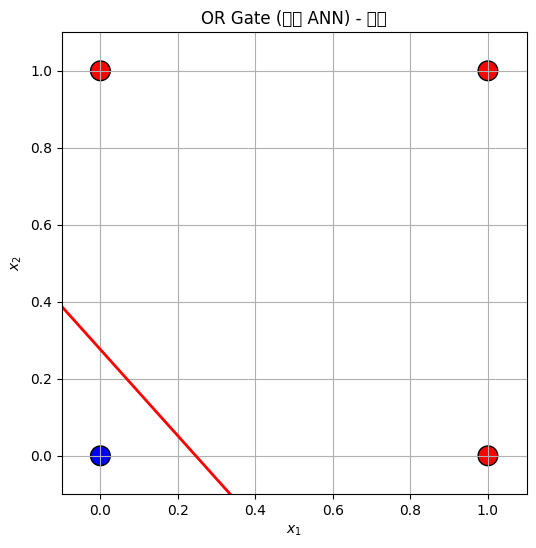

In [29]:
# 시각화 (결정 경계 직선)
plt.figure(figsize=(6,6))
colors = ['blue' if label == 0 else 'red' for label in y.flatten()]
plt.scatter(X[:,0], X[:,1], c=colors, s=200, edgecolors='k')

x_vals = np.linspace(-0.1, 1.1, 100)
y_vals = -(w1 * x_vals + b) / w2
plt.plot(x_vals, y_vals, 'r-', linewidth=2)

plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title("OR Gate (단층 ANN) - 수정")
plt.grid(True)
plt.show()
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

---

# XOR 게이트 (ANN)

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [18]:
# 데이터 (XOR 게이트)
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

In [19]:
# 모델 (단층 ANN)
model = Sequential()
model.add(Dense(1, input_dim=2, activation='sigmoid'))  # 은닉층 없음
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X, y, epochs=500, verbose=0)

# 가중치와 절편
weights = model.layers[0].get_weights()[0]
bias = model.layers[0].get_weights()[1]
w1, w2 = weights[0][0], weights[1][0]
b = bias[0]

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54056 (\N{HANGUL SYLLABLE PAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


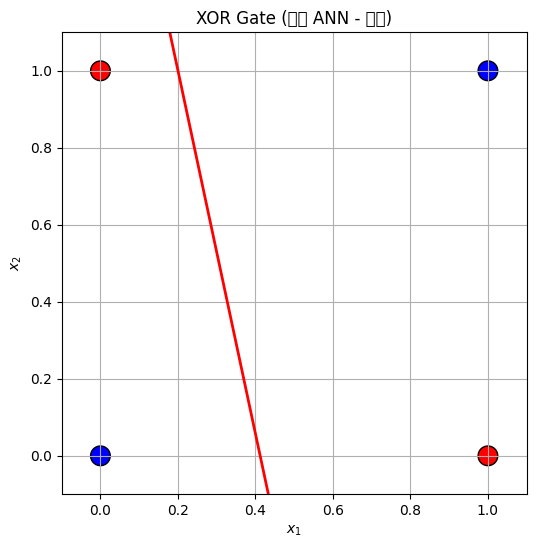

In [20]:
# 시각화 (결정 경계 직선)
plt.figure(figsize=(6,6))
colors = ['blue' if label == 0 else 'red' for label in y.flatten()]
plt.scatter(X[:,0], X[:,1], c=colors, s=200, edgecolors='k')

# 결정 경계 직선: w1*x1 + w2*x2 + b = 0 => x2 = -(w1*x1 + b)/w2
x_vals = np.linspace(-0.1, 1.1, 100)
y_vals = -(w1 * x_vals + b) / w2
plt.plot(x_vals, y_vals, 'r-', linewidth=2)

# 설정
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title("XOR Gate (단층 ANN - 실패)")
plt.grid(True)
plt.show()

XOR 문제는 선형적으로 분리 불가능하기 때문에 실패하게 됩니다.

---

# XOR 게이트 (DNN)

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [22]:
# 데이터 (XOR 게이트)
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

In [23]:
# 모델 (DNN)
model = Sequential()
model.add(Dense(4, input_dim=2, activation='relu'))  # 은닉층
model.add(Dense(1, activation='sigmoid'))           # 출력층
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X, y, epochs=1000, verbose=0)

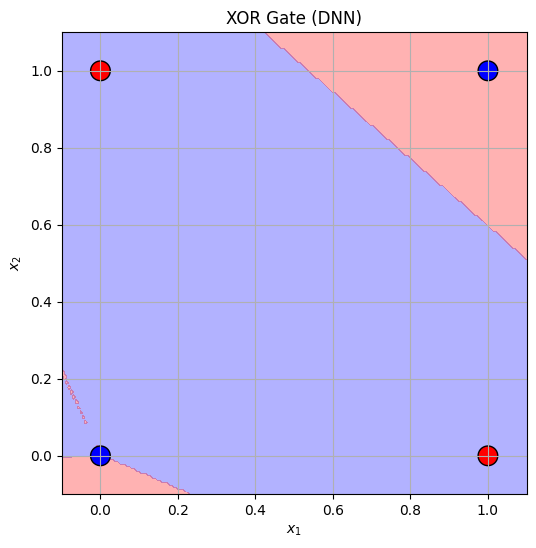

In [24]:
# 비선형 결정 경계 시각화
xx, yy = np.meshgrid(np.linspace(-0.1, 1.1, 200), np.linspace(-0.1, 1.1, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid, verbose=0).reshape(xx.shape)

plt.figure(figsize=(6,6))
plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.3, colors=['blue','red'])

# 데이터 점
colors = ['blue' if label == 0 else 'red' for label in y.flatten()]
plt.scatter(X[:,0], X[:,1], c=colors, s=200, edgecolors='k')

# 설정
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title("XOR Gate (DNN)")
plt.grid(True)
plt.show()

 DNN은 여러 개의 직선을 조합하여 비선형 결정 경계를 만들 수 있기 때문에, 선형적으로 분리할 수 없는 XOR 게이트도 분리할 수 있습니다.